## HW4 - CORDIC 

In [193]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os

%config InlineBackend.figure_format = 'retina'

DATA_DIR = "Final/00_TESTBED/src"

### Result 1 - Find S(N) versus N

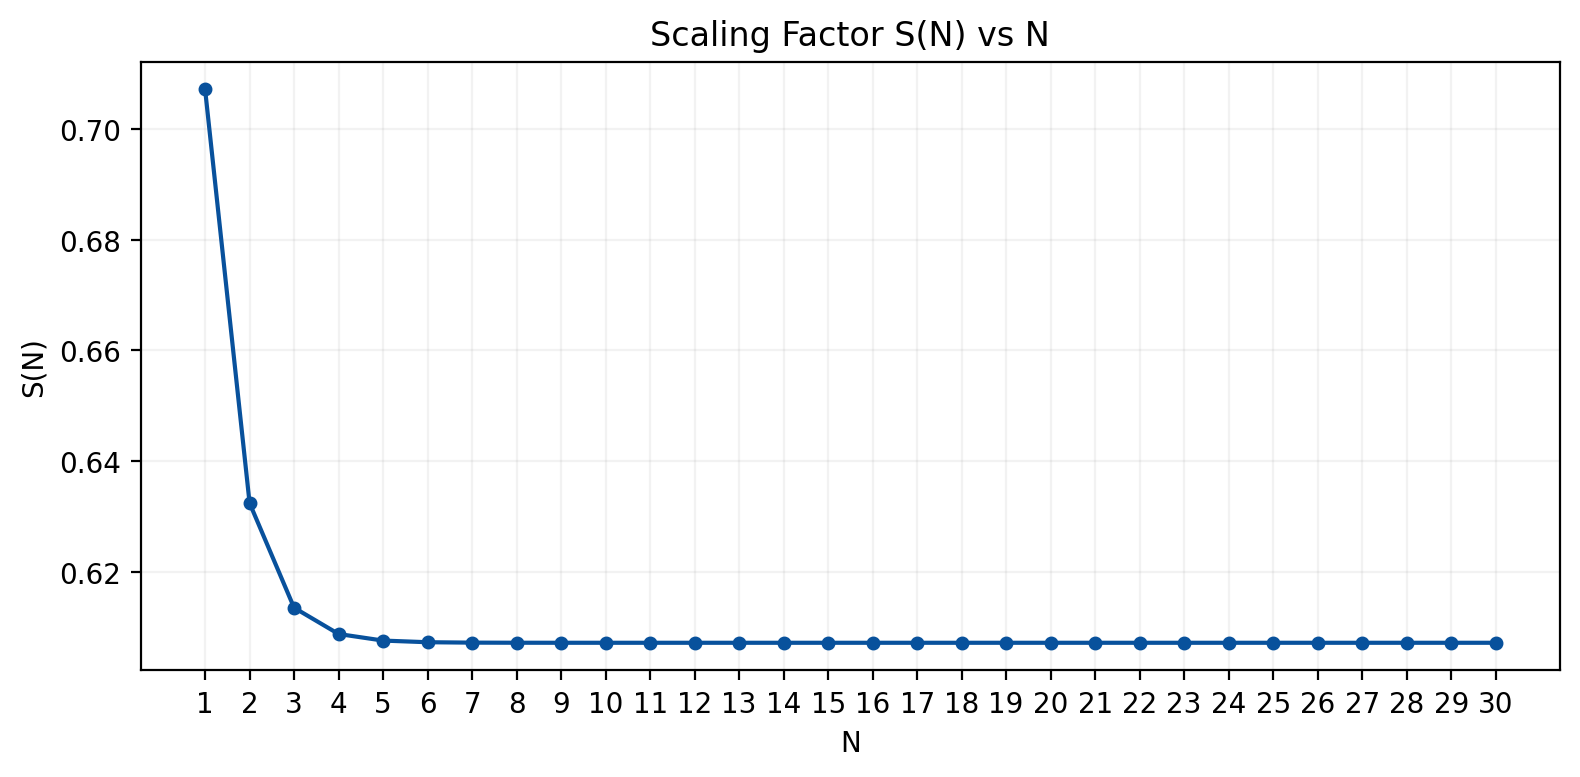

In [194]:
N_max = 30
N_values = np.arange(1, N_max + 1)
S_values = []

for N in N_values:
    product = 1.0
    for i in range(N):
        product *= np.sqrt(1 + 2**(-2*i))
    S_values.append(1.0 / product)

plt.figure(figsize=(8, 4))
plt.plot(N_values, S_values, marker='o', markersize=4, color='#08519c')
plt.xlabel('N')
plt.ylabel('S(N)')
plt.title('Scaling Factor S(N) vs N')
plt.xticks(N_values)
plt.grid(True, color='gray', alpha=0.1)
plt.tight_layout()
plt.show()

### Result 2 - Average Absolute Phase Error vs Fractional Wordlength
找 X 跟 Y 應該要用多少定點數位元才能夠滿足門檻

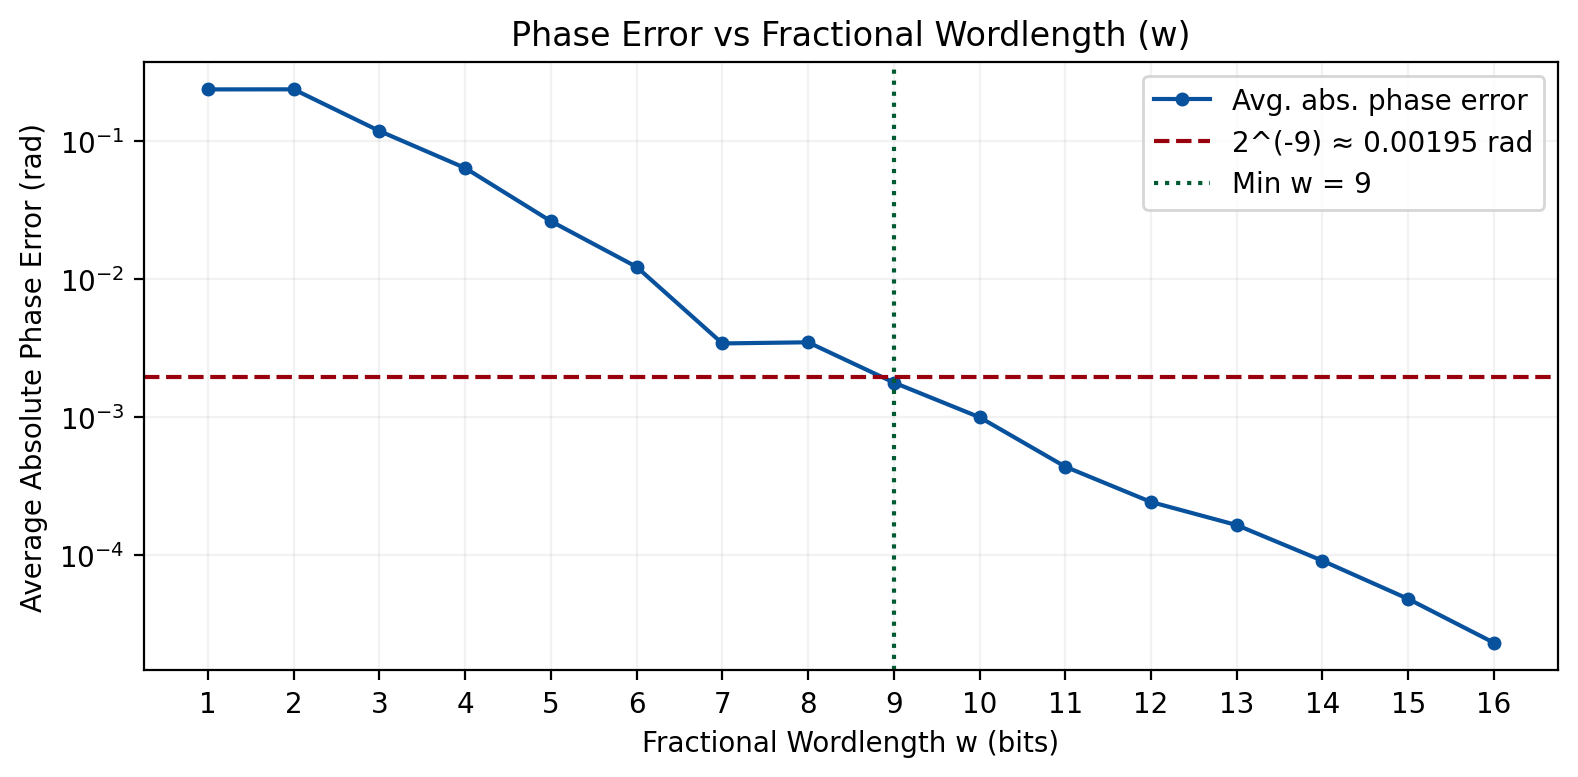

Minimum w satisfying avg error < 2^(-9): w = 9
Total bits per sample: w+2 = 11  (1 sign + 1 integer + 9 fractional)


In [197]:
# Parameters: I=9, beta = mod(9,2)+1 = 2
beta = 2
m_values = np.arange(10)
alpha_m = (4*m_values + beta) / 20 * np.pi

X_true = np.cos(alpha_m)
Y_true = np.sin(alpha_m)

phase_ref = np.arctan2(Y_true, X_true)

def quantize(val, w):
    return np.round(val * 2**(w)) / 2**(w)

def cordic_phase(X0, Y0, w_xy, N, w_e=None):
    phase_adjust = 0.0

    if X0 < 0:
        phase_adjust = np.pi if Y0 >= 0 else -np.pi
        X0, Y0 = -X0, -Y0

    Xi = int(np.floor(X0 * 2**w_xy))
    Yi = int(np.floor(Y0 * 2**w_xy))

    theta = 0.0

    for i in range(N):
        mu = -1 if Yi > 0 else 1
        elem_angle = np.arctan(2.0**(-i))
        if w_e is not None:
            elem_angle = quantize(elem_angle, w_e)

        dX = Yi >> i
        dY = Xi >> i

        Xi_new = Xi - mu * dX
        Yi_new = Yi + mu * dY

        theta = theta - mu * elem_angle

        Xi = Xi_new
        Yi = Yi_new

    return theta + phase_adjust

# Sweep w = 1..16, N = 20
N_iter = 20
w_values = np.arange(1, 17)
avg_errors = []

for w in w_values:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], w, N_iter) - phase_ref[m])
              for m in range(10)]
    avg_errors.append(np.mean(errors))

avg_errors = np.array(avg_errors)

threshold = 2.0**(-9)
valid_w = w_values[avg_errors < threshold]
min_w = int(valid_w[0]) if len(valid_w) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_values, avg_errors, marker='o', markersize=4, color='#08519c', label='Avg. abs. phase error')
plt.axhline(threshold, color='#99000d', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_w is not None:
    plt.axvline(min_w, color='#005a32', linestyle=':', label=f'Min w = {min_w}')
plt.xlabel('Fractional Wordlength w (bits)')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title('Phase Error vs Fractional Wordlength (w)')
plt.xticks(w_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

K_N = math.prod(math.sqrt(1 + 2**(-2*i)) for i in range(N_iter))
print(f"Minimum w satisfying avg error < 2^(-9): w = {min_w}")
print(f"Total bits per sample: w+2 = {min_w+2}  (1 sign + 1 integer + {min_w} fractional)")

### Result 3

#### Phase Error vs Number of Micro-rotations
找跌代次數 S 到底要是多少才可以滿足門檻

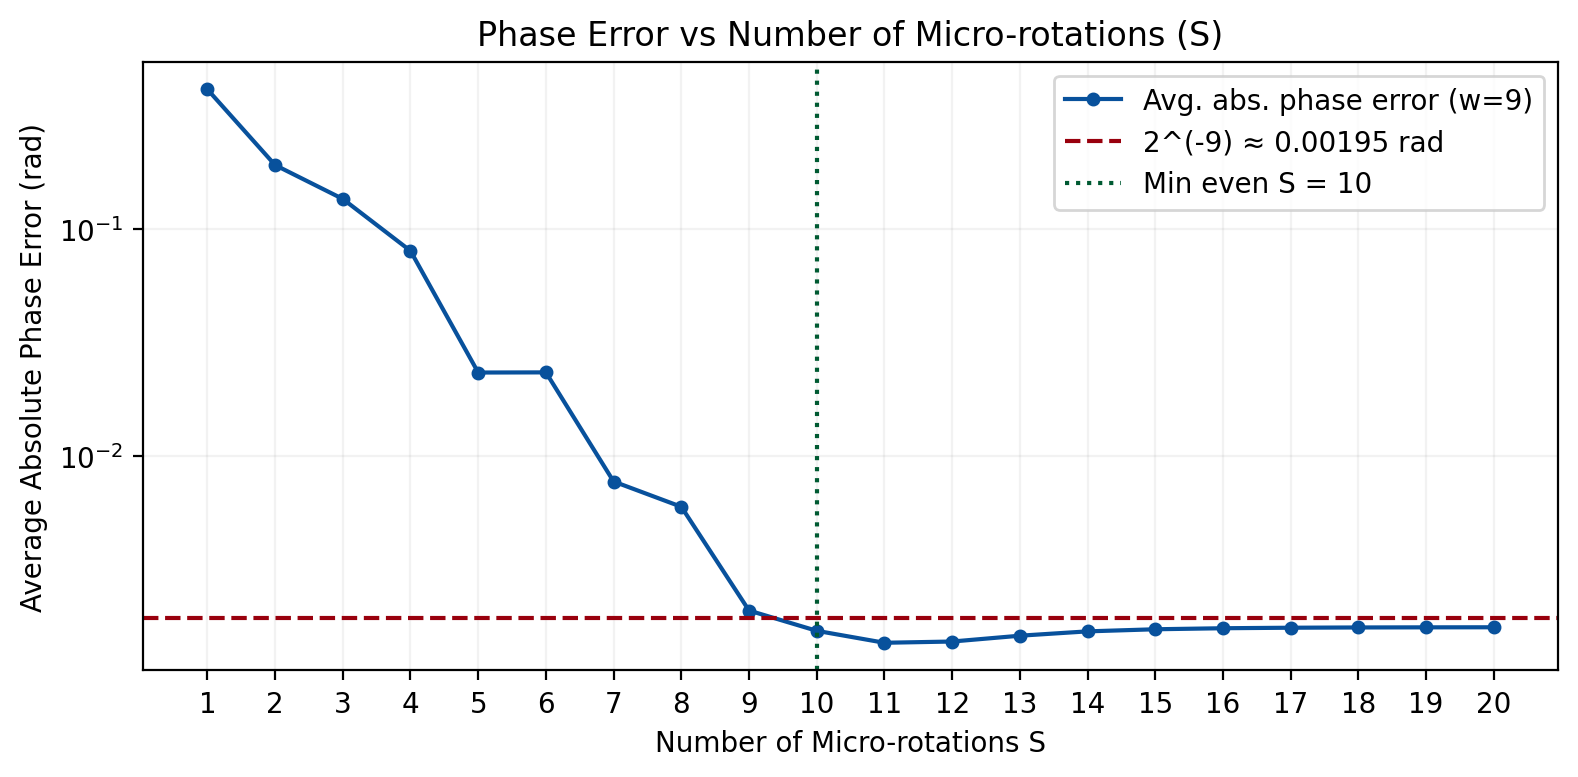

Minimum even S satisfying avg error < 2^(-9): S = 10


In [198]:
S_range = np.arange(1, 21)
avg_errors_S = []

for S in S_range:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], min_w, S) - phase_ref[m])
              for m in range(10)]
    avg_errors_S.append(np.mean(errors))

avg_errors_S = np.array(avg_errors_S)

valid_S = S_range[(avg_errors_S < threshold) & (S_range % 2 == 0)]
min_S = int(valid_S[0]) if len(valid_S) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(S_range, avg_errors_S, marker='o', markersize=4, color='#08519c', label=f'Avg. abs. phase error (w={min_w})')
plt.axhline(threshold, color='#99000d', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_S is not None:
    plt.axvline(min_S, color='#005a32', linestyle=':', label=f'Min even S = {min_S}')
plt.xlabel('Number of Micro-rotations S')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title(f'Phase Error vs Number of Micro-rotations (S)')
plt.xticks(S_range)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

print(f"Minimum even S satisfying avg error < 2^(-9): S = {min_S}")

#### Phase Error vs Elementary Angle Wordlength
找 Elementary Angles 的定點數位寬要是多少才能夠滿足門檻

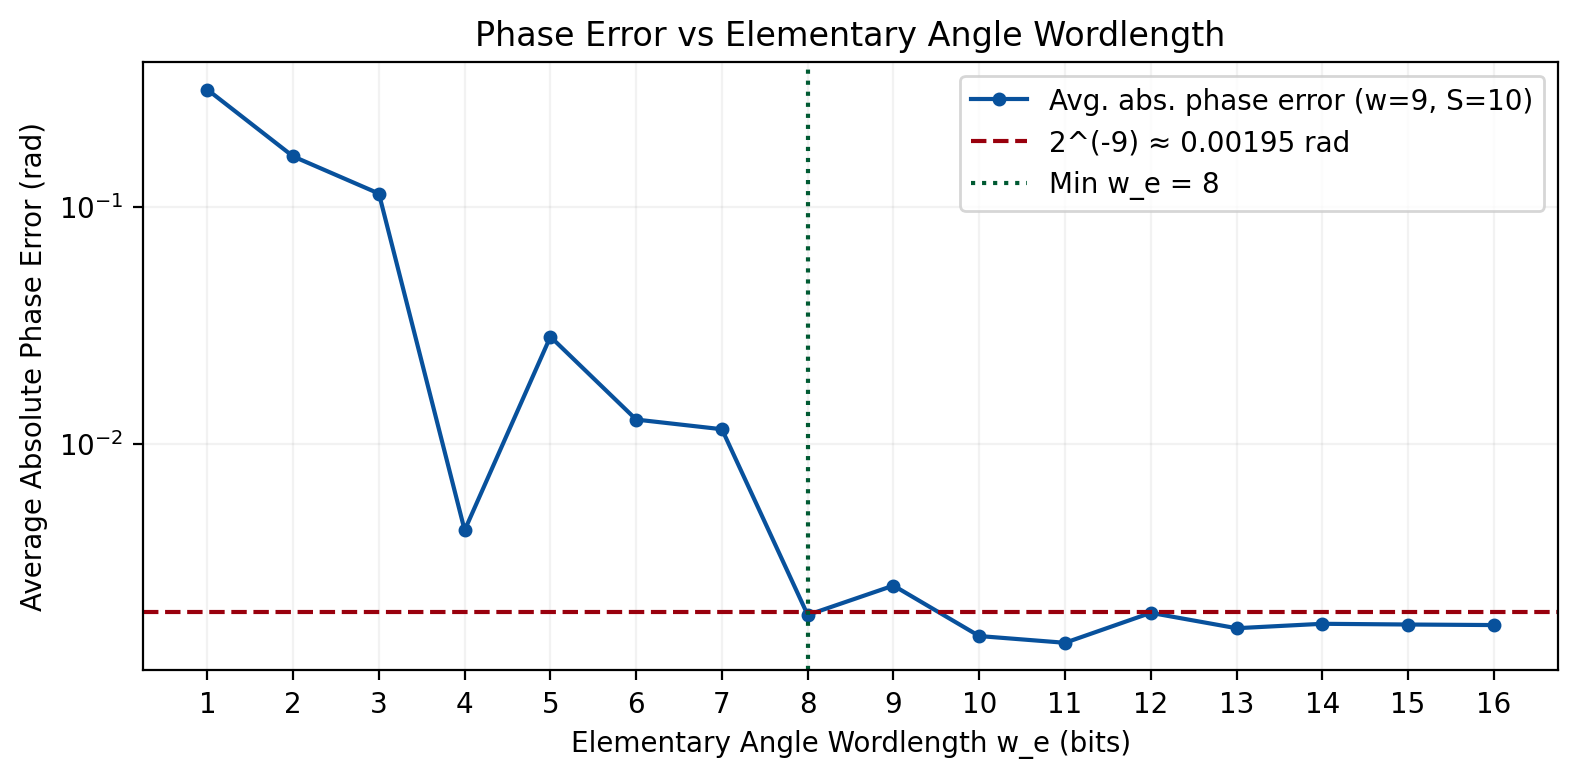

Minimum w_e satisfying avg error < 2^(-9): w_e = 8

Elementary Angles LUT (S=10 stages):
  i          Float           Quantized         Binary (S|II.frac)
-------------------------------------------------------------------
  0      0.7853981634      0.7851562500        000.1100100100
  1      0.4636476090      0.4638671875        000.0111011011
  2      0.2449786631      0.2451171875        000.0011111011
  3      0.1243549945      0.1240234375        000.0001111111
  4      0.0624188100      0.0625000000        000.0001000000
  5      0.0312398334      0.0312500000        000.0000100000
  6      0.0156237286      0.0156250000        000.0000010000
  7      0.0078123411      0.0078125000        000.0000001000
  8      0.0039062301      0.0039062500        000.0000000100
  9      0.0019531225      0.0019531250        000.0000000010


In [ ]:
w_e_values = np.arange(1, 17)
avg_errors_e = []

for w_e in w_e_values:
    errors = [abs(cordic_phase(X_true[m], Y_true[m], min_w, min_S, w_e=w_e) - phase_ref[m])
              for m in range(10)]
    avg_errors_e.append(np.mean(errors))

avg_errors_e = np.array(avg_errors_e)

valid_w_e = w_e_values[avg_errors_e < threshold]
min_w_e = int(valid_w_e[0]) if len(valid_w_e) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_e_values, avg_errors_e, marker='o', markersize=4, color='#08519c',
             label=f'Avg. abs. phase error (w={min_w}, S={min_S})')
plt.axhline(threshold, color='#99000d', linestyle='--', label=f'2^(-9) ≈ {threshold:.5f} rad')
if min_w_e is not None:
    plt.axvline(min_w_e, color='#005a32', linestyle=':', label=f'Min w_e = {min_w_e}')
plt.xlabel('Elementary Angle Wordlength w_e (bits)')
plt.ylabel('Average Absolute Phase Error (rad)')
plt.title(f'Phase Error vs Elementary Angle Wordlength')
plt.xticks(w_e_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

print(f"Minimum w_e satisfying avg error < 2^(-9): w_e = {min_w_e}")

print(f"\nElementary Angles LUT (S={min_S} stages):")
print(f"{'i':>3} {'Float':>14}  {'Quantized':>18} {'Binary (S|II.frac)':>26}")
print("-" * 67)

min_w_e = 10 # 調整成 10 bits fractional
for i in range(min_S):
    angle_f = np.arctan(2.0**(-i))
    angle_q = quantize(angle_f, min_w_e)
    int_bits = int(np.round(angle_q * 2**min_w_e))
    binary_str = '000.' + format(int_bits, f'0{min_w_e}b')
    print(f"{i:>3}  {angle_f:>16.10f}  {angle_q:>16.10f}  {binary_str:>20}")

### Result 5 - CSD Representation of Scaling Factor S(N)
要把 Scaling Factor 轉換成 CSD 表示法，並分析轉成 CSD 所帶來的誤差

S(10) = 0.6072533211


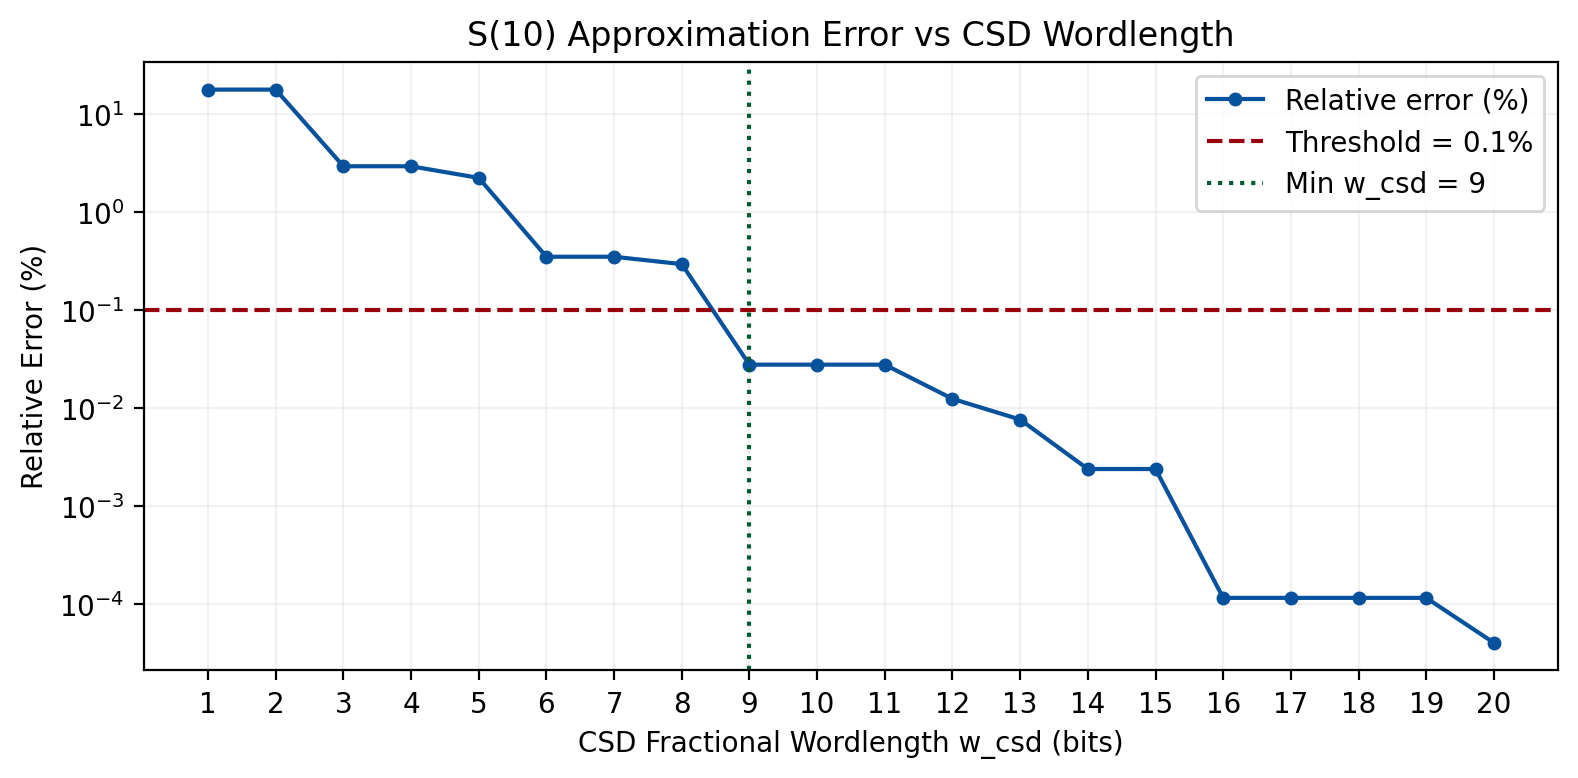


Minimum w_csd satisfying error < 0.1%: w_csd = 9
S_true  = 0.6072533211
S_csd   = 0.6074218750
Error   = 0.0278%

Shift-and-add block (S = 0.607421875):
   Shift   Digit  Operation
  -----------------------------------
       1      +1  + (X >> 1)
       3      +1  + (X >> 3)
       6      -1  - (X >> 6)
       9      -1  - (X >> 9)

Non-zero CSD digits : 4
Adders required     : 3


In [201]:
N_mag = 10
S_true = 1.0 / math.prod(math.sqrt(1 + 2**(-2*i)) for i in range(N_mag))
print(f"S({N_mag}) = {S_true:.10f}")

def to_csd(value, n_frac_bits):
    n = int(np.round(value * 2**n_frac_bits))
    digits = {}
    pos = -n_frac_bits
    while n != 0:
        if n & 1:
            d = -1 if (n & 3) == 3 else 1
            digits[pos] = d
            n -= d
        n >>= 1
        pos += 1
    csd_val = sum(d * 2.0**p for p, d in digits.items())
    return csd_val, digits

threshold_csd = 0.1
w_csd_values = np.arange(1, 21)
errors_csd = []

for w_csd in w_csd_values:
    S_csd, _ = to_csd(S_true, w_csd)
    errors_csd.append(abs(S_true - S_csd) / S_true * 100)

errors_csd = np.array(errors_csd)

valid_csd = w_csd_values[errors_csd < threshold_csd]
min_w_csd = int(valid_csd[0]) if len(valid_csd) > 0 else None

# Plot
plt.figure(figsize=(8, 4))
plt.semilogy(w_csd_values, errors_csd, marker='o', markersize=4, color='#08519c', label='Relative error (%)')
plt.axhline(threshold_csd, color='#99000d', linestyle='--', label=f'Threshold = 0.1%')
if min_w_csd is not None:
    plt.axvline(min_w_csd, color='#005a32', linestyle=':', label=f'Min w_csd = {min_w_csd}')
plt.xlabel('CSD Fractional Wordlength w_csd (bits)')
plt.ylabel('Relative Error (%)')
plt.title(f'S({N_mag}) Approximation Error vs CSD Wordlength')
plt.xticks(w_csd_values)
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.minorticks_off()
plt.tight_layout()
plt.show()

S_csd_final, digits_final = to_csd(S_true, min_w_csd)
nonzero = {p: d for p, d in digits_final.items() if d != 0}
n_nonzero = len(nonzero)

print(f"\nMinimum w_csd satisfying error < 0.1%: w_csd = {min_w_csd}")
print(f"S_true  = {S_true:.10f}")
print(f"S_csd   = {S_csd_final:.10f}")
print(f"Error   = {abs(S_true - S_csd_final) / S_true * 100:.4f}%")
print(f"\nShift-and-add block (S = {S_csd_final}):")
print(f"  {'Shift':>6}  {'Digit':>6}  Operation")
print("  " + "-" * 35)
for p in sorted(nonzero.keys(), reverse=True):
    d = nonzero[p]
    shift = -p
    sign = "+" if d == 1 else "-"
    print(f"  {shift:>6}  {d:>+6}  {sign} (X >> {shift})")
print(f"\nNon-zero CSD digits : {n_nonzero}")
print(f"Adders required     : {n_nonzero - 1}")

### Result 6 - Initial Stage Design
生成 PI 的量化定點數

In [202]:
w_phase = min_w_e  # use same fractional width as elementary angle LUT

pi_float = np.pi
pi_fixed  = int(np.round( pi_float * 2**w_phase))
neg_pi_fixed = -pi_fixed                          

pi_quantized     =  pi_fixed  / 2**w_phase
neg_pi_quantized = neg_pi_fixed / 2**w_phase

# Binary representation: 1S + 2I + w_phase F
def to_fixed_bin(int_val, w_frac, n_int=2):
    """Convert signed integer (scaled by 2^w_frac) to binary string: S II.frac"""
    total_mag_bits = n_int + w_frac
    if int_val >= 0:
        sign_bit = '0'
        bits = format(int_val, f'0{total_mag_bits}b')
    else:
        # two's complement
        sign_bit = '1'
        bits = format((1 << total_mag_bits) + int_val, f'0{total_mag_bits}b')
    return sign_bit + '_' + bits[:n_int] + '.' + bits[n_int:]

pi_bin     = to_fixed_bin( pi_fixed, w_phase)
neg_pi_bin = to_fixed_bin(neg_pi_fixed, w_phase)

print(f"Phase Adjust constants  (1S + 2I + {w_phase}F,  total {w_phase+3} bits)")
print(f"  +π  float = {pi_float:.10f}")
print(f"  +π  fixed = {pi_quantized:.10f}  (integer = {pi_fixed:5d})  binary = {pi_bin}")
print(f"  -π  float = {-pi_float:.10f}")
print(f"  -π  fixed = {neg_pi_quantized:.10f}  (integer = {neg_pi_fixed:5d})  binary = {neg_pi_bin}")
print(f"\n  Quantization error: {abs(pi_float - pi_quantized):.6e} rad")

Phase Adjust constants  (1S + 2I + 10F,  total 13 bits)
  +π  float = 3.1415926536
  +π  fixed = 3.1416015625  (integer =  3217)  binary = 0_11.0010010001
  -π  float = -3.1415926536
  -π  fixed = -3.1416015625  (integer = -3217)  binary = 1_00.1101101111

  Quantization error: 8.908910e-06 rad


### Result 6 - Test Data Generation
產生 m = 0~9 的 X、Y 測試資料，格式為 **1S 1I 9F（11-bit two's complement）**

In [203]:
# Parameters 
beta      = 2          # mod(9, 2) + 1
W_XY      = 12         # fractional bits  (1S 1I 12F → 14 bits total)
TOTAL_W   = 1 + 1 + W_XY   # 14 bits
m_values  = np.arange(10)

alpha_m = (4 * m_values + beta) / 20 * np.pi
X_float = np.cos(alpha_m)
Y_float = np.sin(alpha_m)

# Quantisation: floor to 1S 1I 12F two's complement 
def to_twos_complement_bin(val, w_frac, total_bits):
    """
    Quantise float val to fixed-point with w_frac fractional bits,
    then return total_bits-wide two's complement binary string.
    Uses floor (arithmetic right-shift compatible, matches hardware).
    """
    scaled = int(np.floor(val * 2**w_frac))          # floor truncation
    if scaled < 0:
        scaled = (1 << total_bits) + scaled           # two's complement wrap
    return format(scaled & ((1 << total_bits) - 1), f'0{total_bits}b')

X_bin = [to_twos_complement_bin(x, W_XY, TOTAL_W) for x in X_float]
Y_bin = [to_twos_complement_bin(y, W_XY, TOTAL_W) for y in Y_float]

# Write .dat files
os.makedirs(DATA_DIR, exist_ok=True)

with open(os.path.join(DATA_DIR, "InX.dat"), "w") as f:
    f.write("\n".join(X_bin) + "\n")

with open(os.path.join(DATA_DIR, "InY.dat"), "w") as f:
    f.write("\n".join(Y_bin) + "\n")

print(f"\nFiles written to: {DATA_DIR}")


Files written to: Final/00_TESTBED/src


### Result 7 - Hardware Implementation Error Analysis
讀取硬體模擬輸出 `OutTheta.dat`（1S 2I 8F），與浮點 arctan2 參考值比較，驗證誤差 < 2⁻⁹ rad。

 m   alpha/pi    arctan2 ref    HW output   |error| (rad)
--------------------------------------------------------
 0   0.100000     0.31415927   0.31152344        2.64e-03
 1   0.300000     0.94247780   0.94433594        1.86e-03
 2   0.500000     1.57079633   1.56933594        1.46e-03
 3   0.700000     2.19911486   2.19726562        1.85e-03
 4   0.900000     2.82743339   2.83007812        2.64e-03
 5   1.100000    -2.82743339  -2.82617188        1.26e-03
 6   1.300000    -2.19911486  -2.19726562        1.85e-03
 7   1.500000    -1.57079633  -1.57226562        1.47e-03
 8   1.700000    -0.94247780  -0.94433594        1.86e-03
 9   1.900000    -0.31415927  -0.31542969        1.27e-03

Output resolution (1 LSB = 2^-10) : 9.7656e-04 rad
Average absolute error             : 1.8157e-03 rad
Threshold 2^-9                     : 1.9531e-03 rad
Average error < 2^-9 ?             : PASS


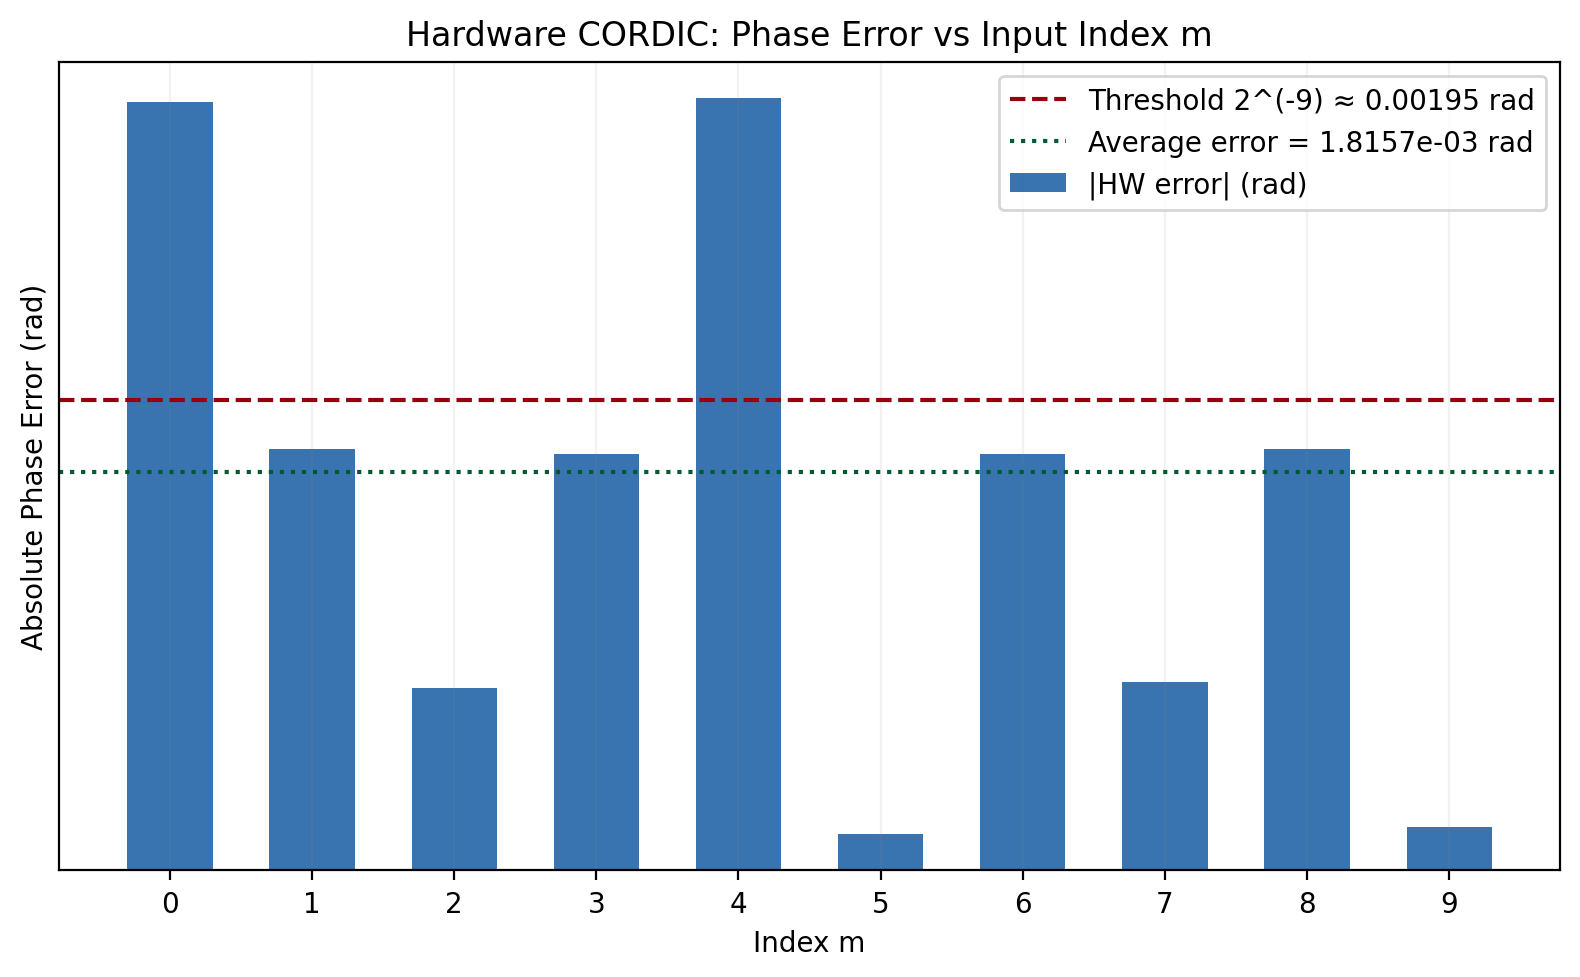

In [204]:
# Parameters
W_THETA  = 10   # fractional bits of OutTheta (1S 2I 10F)
TOTAL_TW = 13   # total bits

# Read OutTheta.dat (hex)
hw_dat = os.path.join(DATA_DIR, "OutTheta.dat")

with open(hw_dat) as f:
    lines = [l.strip() for l in f if l.strip()]

def hex_to_signed_float_theta(hex_str, w_frac, total_bits):
    """Hex string → signed float via two's complement (e.g. 1S 2I 10F)."""
    val = int(hex_str, 16)
    if val >= (1 << (total_bits - 1)):
        val -= (1 << total_bits)
    return val / (2 ** w_frac)

hw_theta = np.array([hex_to_signed_float_theta(l, W_THETA, TOTAL_TW) for l in lines])

# Reference
errors = np.abs(hw_theta - phase_ref)
avg_error = np.mean(errors)

# Print table
print(f"{'m':>2}  {'alpha/pi':>9}  {'arctan2 ref':>13}  {'HW output':>11}  {'|error| (rad)':>14}")
print("-" * 56)
for m in range(10):
    print(f"{m:>2}  {alpha_m[m]/np.pi:>9.6f}  {phase_ref[m]:>13.8f}  {hw_theta[m]:>11.8f}  {errors[m]:>14.2e}")

print(f"\nOutput resolution (1 LSB = 2^-10) : {2**-10:.4e} rad")
print(f"Average absolute error             : {avg_error:.4e} rad")
print(f"Threshold 2^-9                     : {threshold:.4e} rad")
print(f"Average error < 2^-9 ?             : {'PASS' if avg_error < threshold else 'FAIL'}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(10), errors, color='#08519c', alpha=0.8, width=0.6, label='|HW error| (rad)')
ax.set_yscale('log')
ax.axhline(threshold, color='#99000d', linestyle='--', label=f'Threshold 2^(-9) ≈ {threshold:.5f} rad')
ax.axhline(avg_error, color='#005a32', linestyle=':', label=f'Average error = {avg_error:.4e} rad')
ax.set_xlabel('Index m')
ax.set_ylabel('Absolute Phase Error (rad)')
ax.set_title('Hardware CORDIC: Phase Error vs Input Index m')
ax.set_xticks(range(10))
ax.legend()
ax.grid(True, color='gray', alpha=0.1)
ax.minorticks_off()
plt.tight_layout()
plt.show()

### Result 9 - Hardware Magnitude Error Analysis

 m   alpha/pi    Ref √(X²+Y²)    HW output  Rel. error (%)
------------------------------------------------------------
 0   0.100000      1.00000000   1.00024414          0.0244
 1   0.300000      1.00000000   1.00048828          0.0488
 2   0.500000      1.00000000   1.00048828          0.0488
 3   0.700000      1.00000000   1.00024414          0.0244
 4   0.900000      1.00000000   1.00048828          0.0488
 5   1.100000      1.00000000   1.00048828          0.0488
 6   1.300000      1.00000000   1.00073242          0.0732
 7   1.500000      1.00000000   1.00024414          0.0244
 8   1.700000      1.00000000   1.00024414          0.0244
 9   1.900000      1.00000000   1.00073242          0.0732

Output resolution (1 LSB = 2^-12) : 0.0002441
Average relative error            : 0.0439 %
Threshold                         : 0.1000 %
Average error < 0.1% ?            : PASS


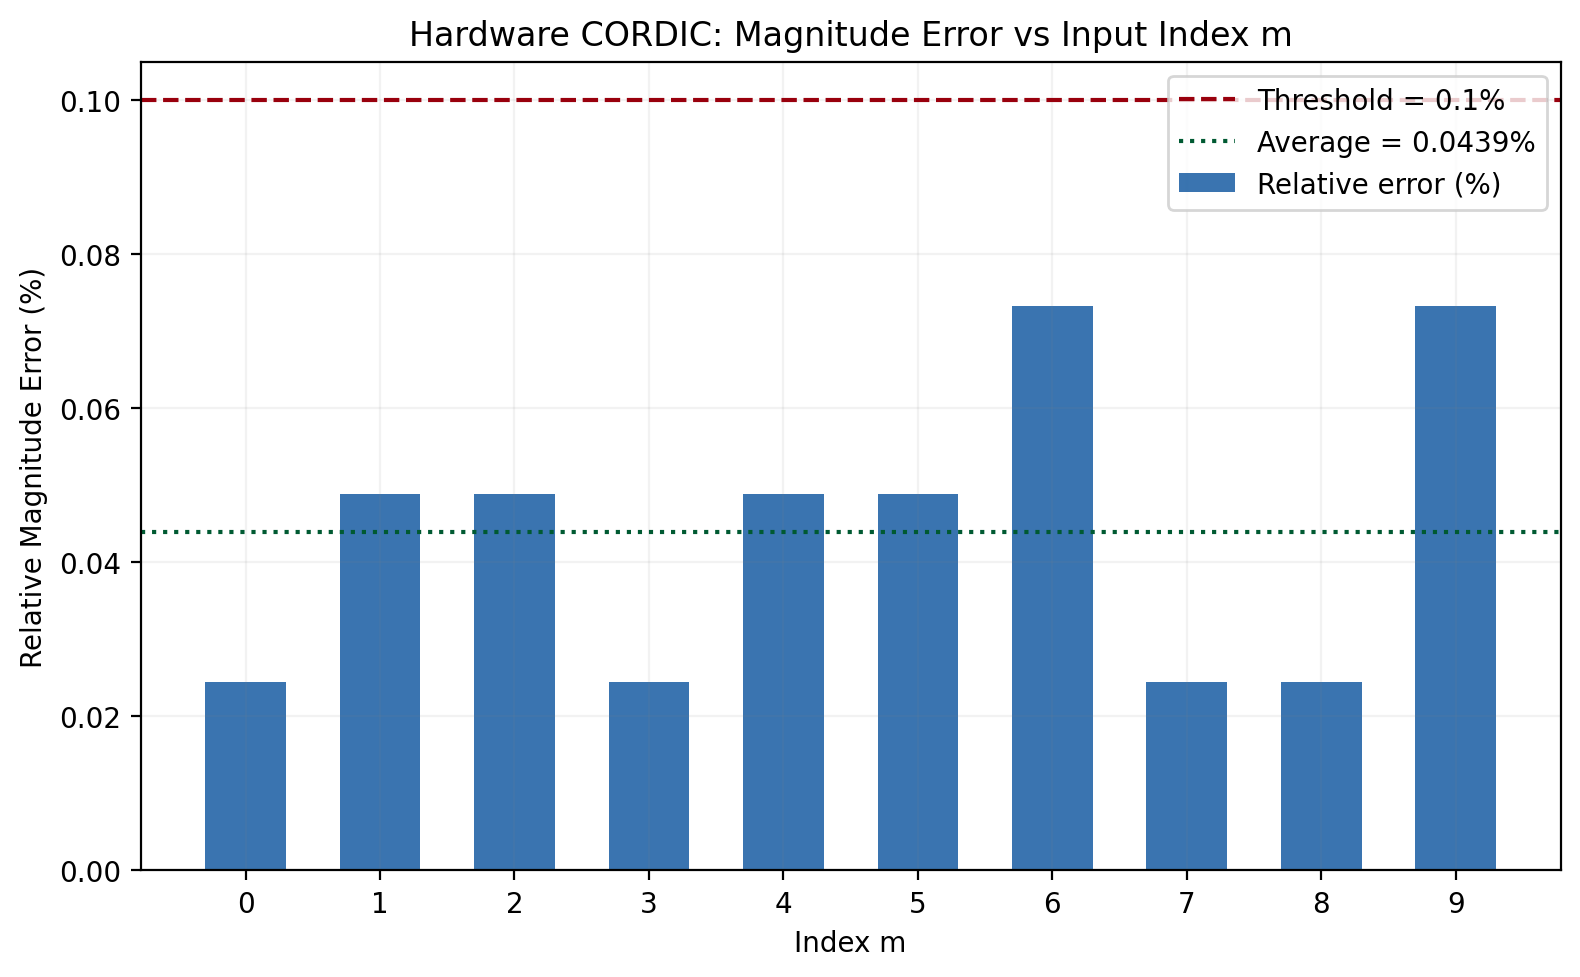

In [205]:
# Parameters
W_MAG    = 12    # fractional bits  (1S 1I 12F → 14 bits total)
TOTAL_MW = 14    # total bits

# Read Magnitude.dat (hex)
mag_dat = os.path.join(DATA_DIR, "Magnitude.dat")

with open(mag_dat) as f:
    lines = [l.strip() for l in f if l.strip()]

def hex_to_signed_float(hex_str, w_frac, total_bits):
    """Hex string → signed float via two's complement (e.g. 1S 1I 12F)."""
    val = int(hex_str, 16)
    if val >= (1 << (total_bits - 1)):
        val -= (1 << total_bits)
    return val / (2 ** w_frac)

hw_mag = np.array([hex_to_signed_float(l, W_MAG, TOTAL_MW) for l in lines])

# Reference
mag_ref = np.sqrt(X_float**2 + Y_float**2)

# Error analysis
abs_errors  = np.abs(hw_mag - mag_ref)
rel_errors  = abs_errors / mag_ref * 100
avg_rel_err = np.mean(rel_errors)
threshold_mag = 0.1  # %

# Print table
print(f"{'m':>2}  {'alpha/pi':>9}  {'Ref √(X²+Y²)':>14}  {'HW output':>11}  {'Rel. error (%)':>14}")
print("-" * 60)
for m in range(10):
    print(f"{m:>2}  {alpha_m[m]/np.pi:>9.6f}  {mag_ref[m]:>14.8f}  {hw_mag[m]:>11.8f}  {rel_errors[m]:>14.4f}")

print(f"\nOutput resolution (1 LSB = 2^-{W_MAG}) : {2**-W_MAG:.7f}")
print(f"Average relative error            : {avg_rel_err:.4f} %")
print(f"Threshold                         : {threshold_mag:.4f} %")
print(f"Average error < 0.1% ?            : {'PASS' if avg_rel_err < threshold_mag else 'FAIL'}")

# Plot
plt.figure(figsize=(8, 5))
plt.bar(range(10), rel_errors, color='#08519c', alpha=0.8, width=0.6, label='Relative error (%)')
plt.axhline(threshold_mag, color='#99000d', linestyle='--', label=f'Threshold = 0.1%')
plt.axhline(avg_rel_err,   color='#005a32', linestyle=':',  label=f'Average = {avg_rel_err:.4f}%')
plt.xlabel('Index m')
plt.ylabel('Relative Magnitude Error (%)')
plt.title('Hardware CORDIC: Magnitude Error vs Input Index m')
plt.xticks(range(10))
plt.legend()
plt.grid(True, color='gray', alpha=0.1)
plt.tight_layout()
plt.show()

### Parameter Explorer — Full Hardware Simulation
模擬整體硬體實現帶來的誤差，因為上面都是個別判斷誤差，這會導致預估硬體實現誤差過於樂觀，因為誤差會累積。

W_XY=12  W_E=10  W_MAG=12  W_CSD=9  N=10

 m   alpha/π        θ ref         θ HW    |Δθ|(rad)   mag ref    mag HW     err%
------------------------------------------------------------------------------
 0   0.10000     0.314159     0.311523     2.64e-03   1.00000   1.00024   0.0244
 1   0.30000     0.942478     0.944336     1.86e-03   1.00000   1.00049   0.0488
 2   0.50000     1.570796     1.569336     1.46e-03   1.00000   1.00049   0.0488
 3   0.70000     2.199115     2.197266     1.85e-03   1.00000   1.00024   0.0244
 4   0.90000     2.827433     2.830078     2.64e-03   1.00000   1.00049   0.0488
 5   1.10000    -2.827433    -2.826172     1.26e-03   1.00000   1.00049   0.0488
 6   1.30000    -2.199115    -2.197266     1.85e-03   1.00000   1.00073   0.0732
 7   1.50000    -1.570796    -1.572266     1.47e-03   1.00000   1.00024   0.0244
 8   1.70000    -0.942478    -0.944336     1.86e-03   1.00000   1.00024   0.0244
 9   1.90000    -0.314159    -0.315430     1.27e-03   1.00000   1.000

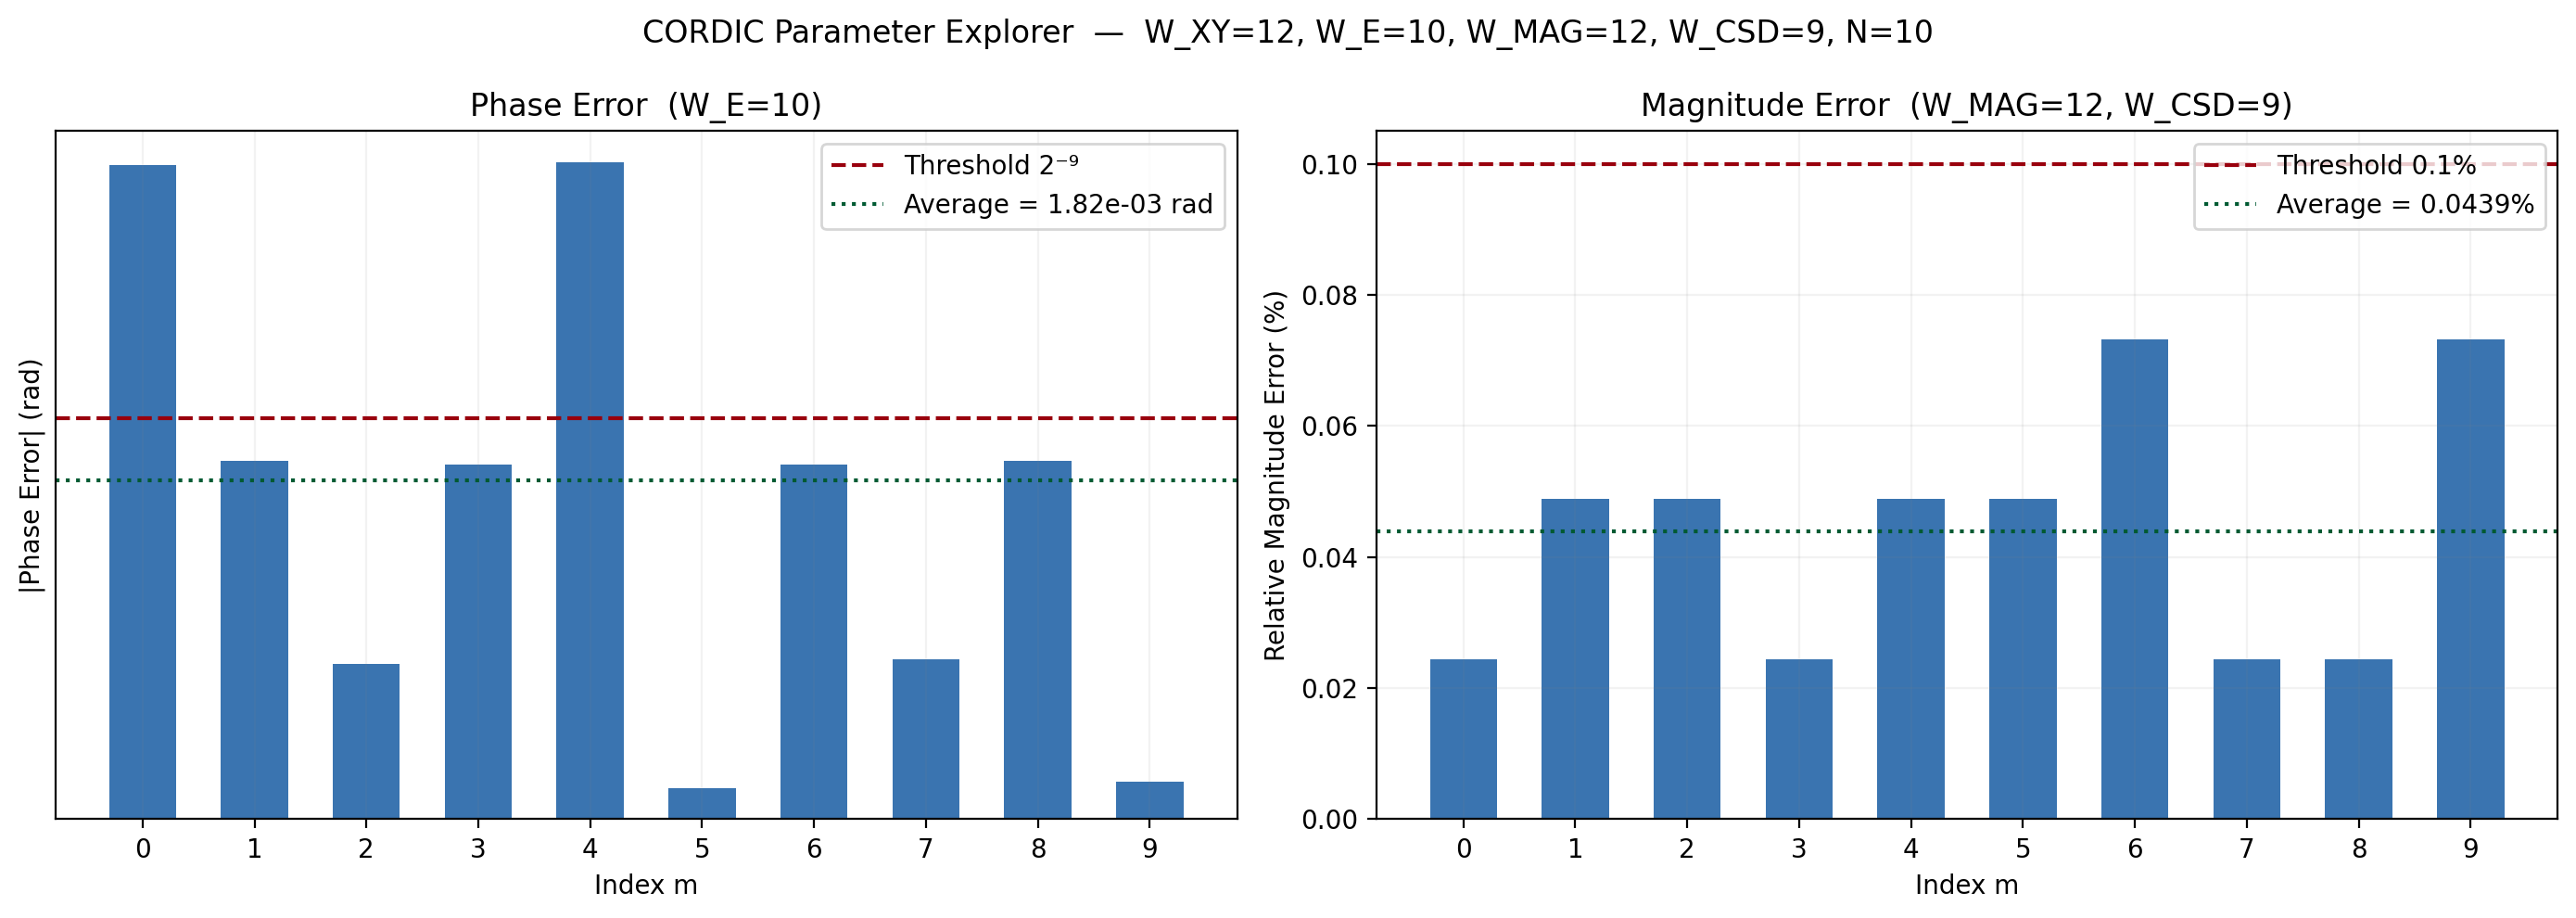

In [209]:
# Parameters
W_XY  = 12  # X/Y fractional bits  (1S 1I W_XY F)
W_E   = 10  # elementary angle / theta fractional bits  (1S 2I W_E F)
W_MAG = 12  # magnitude output fractional bits  (1S 1I W_MAG F)
W_CSD = 9   # CSD S(N) fractional bits
N     = 10  # CORDIC iterations

# Derived
TOTAL_XY  = 1 + 1 + W_XY
TOTAL_T   = 1 + 2 + W_E
TOTAL_MAG = 1 + 1 + W_MAG

def trunc_bits(val, total_bits):
    """Two's complement register truncation."""
    mod = 1 << total_bits
    val = val & (mod - 1)
    if val >= (mod >> 1):
        val -= mod
    return val

# LUT (round, matches Step 3)
theta_e_sim = [int(np.round(np.arctan(2.0**(-i)) * 2**W_E)) for i in range(N)]
pi_sim      = int(np.round(np.pi * 2**W_E))

# CSD S(N)
_, csd_d = to_csd(S_true, W_CSD)
csd_nz   = {p: d for p, d in csd_d.items() if d != 0}

# CORDIC simulation
def cordic_hw_sim(xi, yi):
    if xi < 0:
        phase_adj = pi_sim if yi >= 0 else -pi_sim
        xi, yi = -xi, -yi
    else:
        phase_adj = 0
    theta = 0
    for i in range(N):
        mu    = -1 if yi > 0 else 1
        xi_n  = xi - mu * (yi >> i)
        yi_n  = yi + mu * (xi >> i)
        theta -= mu * theta_e_sim[i]
        xi, yi = xi_n, yi_n
    return trunc_bits(xi, TOTAL_XY), trunc_bits(theta + phase_adj, TOTAL_T)

# CSD magnitude
def csd_mag_sim(xn):
    r = sum(d * (xn >> (-p)) for p, d in csd_nz.items())
    return trunc_bits(r, TOTAL_MAG)

# Inputs (floor, matches to_twos_complement_bin)
X_int = [int(np.floor(x * 2**W_XY)) for x in X_float]
Y_int = [int(np.floor(y * 2**W_XY)) for y in Y_float]

# Run
hw_th, hw_mg = [], []
for m in range(10):
    xi_o, th_o = cordic_hw_sim(X_int[m], Y_int[m])
    hw_th.append(th_o / 2**W_E)
    hw_mg.append(csd_mag_sim(xi_o) / 2**W_MAG)

hw_th = np.array(hw_th)
hw_mg = np.array(hw_mg)

# Errors
ph_err = np.abs(hw_th - phase_ref)
mg_err = np.abs(hw_mg - mag_ref) / mag_ref * 100
avg_ph = np.mean(ph_err)
avg_mg = np.mean(mg_err)
thr_ph = 2.0**(-9)
thr_mg = 0.1

# Table
print(f"W_XY={W_XY}  W_E={W_E}  W_MAG={W_MAG}  W_CSD={W_CSD}  N={N}\n")
print(f"{'m':>2}  {'alpha/π':>8}  {'θ ref':>11}  {'θ HW':>11}  {'|Δθ|(rad)':>11}  {'mag ref':>8}  {'mag HW':>8}  {'err%':>7}")
print("-" * 78)
for m in range(10):
    print(f"{m:>2}  {alpha_m[m]/np.pi:>8.5f}  {phase_ref[m]:>11.6f}  {hw_th[m]:>11.6f}  {ph_err[m]:>11.2e}  {mag_ref[m]:>8.5f}  {hw_mg[m]:>8.5f}  {mg_err[m]:>7.4f}")

print(f"\nPhase     : avg = {avg_ph:.3e} rad   threshold = {thr_ph:.3e}   {'PASS' if avg_ph < thr_ph else 'FAIL'}")
print(f"Magnitude : avg = {avg_mg:.4f} %     threshold = {thr_mg:.4f} %   {'PASS' if avg_mg < thr_mg else 'FAIL'}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(10), ph_err, color='#08519c', alpha=0.8, width=0.6)
ax1.set_yscale('log')
ax1.axhline(thr_ph, color='#99000d', linestyle='--', label=f'Threshold 2⁻⁹')
ax1.axhline(avg_ph, color='#005a32', linestyle=':', label=f'Average = {avg_ph:.2e} rad')
ax1.set_xlabel('Index m')
ax1.set_ylabel('|Phase Error| (rad)')
ax1.set_title(f'Phase Error  (W_E={W_E})')
ax1.set_xticks(range(10))
ax1.legend()
ax1.grid(True, color='gray', alpha=0.1)
ax1.minorticks_off()

ax2.bar(range(10), mg_err, color='#08519c', alpha=0.8, width=0.6)
ax2.axhline(thr_mg, color='#99000d', linestyle='--', label=f'Threshold 0.1%')
ax2.axhline(avg_mg, color='#005a32', linestyle=':', label=f'Average = {avg_mg:.4f}%')
ax2.set_xlabel('Index m')
ax2.set_ylabel('Relative Magnitude Error (%)')
ax2.set_title(f'Magnitude Error  (W_MAG={W_MAG}, W_CSD={W_CSD})')
ax2.set_xticks(range(10))
ax2.legend()
ax2.grid(True, color='gray', alpha=0.1)

plt.suptitle(f'CORDIC Parameter Explorer  —  W_XY={W_XY}, W_E={W_E}, W_MAG={W_MAG}, W_CSD={W_CSD}, N={N}')
plt.tight_layout()
plt.show()